# Heracles vs NaMaster: direct Cl comparison (TR1, real data)

The QML comparison notebook (`TR1_power_spectra_and_covariance_estimation.ipynb`) compares NaMaster against
heracles' *packaged pipeline output* FITS product - but that comparison has two mismatches baked in:

1. heracles' pipeline product is the **raw, mode-coupled** pseudo-Cl, while NaMaster's `compute_full_master`
   result is **mask-deconvolved**.
2. The QML/NaMaster analysis there runs at `n_side=256` (for QML tractability), while heracles' pipeline
   product was made at its native `n_side=1024` - a resolution mismatch on top of the coupling mismatch.

Here we remove both confounds: we run heracles **ourselves**, directly on the same real TR1 shear catalogue,
at heracles' own native `n_side=1024`, and build a NaMaster estimate on the *exact same* mask and shear maps.
We then reconcile coupled vs decoupled explicitly, so the comparison is genuinely apples-to-apples.


In [1]:
import os
import numpy as np
import fitsio
import healpy as hp
import pymaster as nmt
import heracles
import heracles.healpy
from matplotlib import pyplot as plt

root_filepath = '/home/vscode/WeakLensingQML'
tr1_dir = f'{root_filepath}/TR1'
pipeline_input_dir = f'{tr1_dir}/pipeline_input'


In [11]:
# Match heracles' native resolution (n_side=1024) exactly - no downgrading, unlike the QML notebook.
# The real TR1 mask covers only f_sky~0.0034 of the sky (a narrow strip), so the mode-coupling
# matrix only decorrelates over a wide range in ell (roughly Delta_ell ~ 1/sqrt(f_sky) ~ 17-20).
# Bandpowers must be substantially wider than this or NaMaster's decoupling becomes ill-conditioned
# (oscillating / even negative "EE" bandpowers) - hence the wide, equal-width bins below.
nside = 1024
tom_bin = 1
lmin = 10
lmax = 800
nlbins = 6


## Load the real TR1 mask and shear catalogue


In [3]:
def read_partial_map(path, nside, *, nest=False):
    """
    Read a HEALPix map in "partial" format from *path* and return it at resolution *nside*.
    The returned NSIDE cannot be larger than the NSIDE of the stored map.
    """
    data, header = fitsio.read(path, header=True)
    nside_in = header['NSIDE']
    fact = (nside_in // nside) ** 2
    if fact == 0:
        raise ValueError(f'requested NSIDE={nside} greater than map NSIDE={nside_in}')
    out = np.zeros(12 * nside ** 2)
    ipix, wht = data['PIXEL'], data['WEIGHT']
    order = header['ORDERING']
    if order == 'RING':
        ipix = hp.ring2nest(nside_in, ipix)
    elif order != 'NESTED':
        raise ValueError(f'unknown pixel ordering {order} in map')
    ipix = ipix // fact
    if not nest:
        ipix = hp.nest2ring(nside, ipix)
    np.add.at(out, ipix, wht / fact)
    return out


# Real Euclid effective-coverage map, at heracles' own native n_side (no downgrading)
coverage_filepath = f'{pipeline_input_dir}/EUC_LE3_VMPZ-ID_HPEFFECTIVECOVERAGE-CONCAT-20251204T094108.787432Z_0.12.fits'
coverage = read_partial_map(coverage_filepath, nside)
mask = (coverage > 0)

she_catalog_filepath = f'{pipeline_input_dir}/EUC_LE3_WLCATALOG-CONCAT-20251218T164508.418188Z_00.00.fits'


In [4]:
she_cols = ['SHE_RA', 'SHE_DEC', 'SHE_E1_CORRECTED', 'SHE_E2_CORRECTED', 'SHE_WEIGHT', 'TOM_BIN_ID']
she_data = fitsio.read(she_catalog_filepath, columns=she_cols)
she_data = she_data[she_data['TOM_BIN_ID'] == tom_bin]

she_ra = she_data['SHE_RA'].astype(np.float64)
she_dec = she_data['SHE_DEC'].astype(np.float64)
she_weight = she_data['SHE_WEIGHT'].astype(np.float64)
she_e1 = -she_data['SHE_E1_CORRECTED'].astype(np.float64)  # sign matches the pipeline's SHE field definition
she_e2 = she_data['SHE_E2_CORRECTED'].astype(np.float64)


## Compute the heracles Cl (run directly, not the packaged pipeline product)


In [12]:
catalogShe = heracles.FitsCatalog(she_catalog_filepath)
she_cat = catalogShe[f'TOM_BIN_ID == {tom_bin}']
she_cat.visibility = coverage
she_catalogs = {tom_bin: she_cat}

mapper = heracles.healpy.HealpixMapper(nside, lmax)

fieldsShe = {
    'SHE': heracles.Shears(
        mapper,
        'SHE_RA', 'SHE_DEC',
        '-SHE_E1_CORRECTED', 'SHE_E2_CORRECTED',
        'SHE_WEIGHT',
        mask='WHT',
    ),
    'WHT': heracles.Weights(mapper, 'SHE_RA', 'SHE_DEC', 'SHE_WEIGHT'),
}

data_she = heracles.map_catalogs(fieldsShe, she_catalogs, parallel=True)
alms_she = heracles.transform(fieldsShe, data_she)


In [13]:
# Full per-ell (unbinned, mode-coupled) SHE-SHE spectrum - kept unbinned so we can
# decouple it exactly below, in addition to the binned version for direct plotting.
cls_she_unbinned = heracles.angular_power_spectra(alms_she, include=[('SHE', 'SHE')])

# Wide, equal-width bins (see note above on why this mask needs wide bandpowers)
ledges = np.linspace(lmin, lmax, nlbins + 1)
cls_she_binned = heracles.binned(cls_she_unbinned, ledges)

she_she_key = ('SHE', 'SHE', tom_bin, tom_bin)
ell_heracles = np.array(cls_she_binned[she_she_key].ell)
cl_EE_heracles = np.array(cls_she_binned[she_she_key][0, 0])
cl_BB_heracles = np.array(cls_she_binned[she_she_key][1, 1])


## Compute the NaMaster (PCl) Cl on the same mask and shear catalogue


In [7]:
# Pixelise the same shear catalogue directly onto a HEALPix map, at the same n_side, so
# NaMaster sees exactly the same data heracles just used (a simple, weighted per-pixel mean)
n_pix = 12 * nside ** 2
she_pix = hp.ang2pix(nside, she_ra, she_dec, lonlat=True)

sum_weight = np.zeros(n_pix)
sum_weight_e1 = np.zeros(n_pix)
sum_weight_e2 = np.zeros(n_pix)
np.add.at(sum_weight, she_pix, she_weight)
np.add.at(sum_weight_e1, she_pix, she_weight * she_e1)
np.add.at(sum_weight_e2, she_pix, she_weight * she_e2)

with np.errstate(invalid='ignore', divide='ignore'):
    map_gamma1 = np.where(sum_weight > 0, sum_weight_e1 / sum_weight, 0.0)
    map_gamma2 = np.where(sum_weight > 0, sum_weight_e2 / sum_weight, 0.0)

map_gamma1 *= mask
map_gamma2 *= mask


In [14]:
# Use the same (log-spaced) bandpower edges as heracles' `ledges` above, so both methods
# are compared on identical bins
ell_edges_int = np.unique(np.round(ledges).astype(int))
bins = nmt.NmtBin.from_edges(ell_edges_int[:-1], ell_edges_int[1:])
ell_bp = bins.get_effective_ells()

field_mask = nmt.NmtField(mask, None, spin=2, lmax=bins.lmax)
field_shear = nmt.NmtField(mask, [map_gamma1, map_gamma2], lmax=bins.lmax)

wsp = nmt.NmtWorkspace()
wsp.compute_coupling_matrix(field_mask, field_mask, bins)

cl_EE_namaster, cl_BB_namaster = nmt.compute_full_master(field_shear, field_shear, bins)[[0, 3]]


## Reconcile coupled vs decoupled

heracles' `angular_power_spectra` returns the raw, mode-coupled pseudo-Cl (it does not deconvolve by
default), while NaMaster's `compute_full_master` returns the mask-deconvolved Cl. To compare like-for-like,
decouple heracles' unbinned Cl with NaMaster's own mixing matrix (`wsp`, built from this exact mask) before
binning it onto the same bandpowers.


In [15]:
cl_EE_heracles_raw = np.array(cls_she_unbinned[she_she_key][0, 0])
cl_BB_heracles_raw = np.array(cls_she_unbinned[she_she_key][1, 1])
ell_full_heracles = np.arange(len(cl_EE_heracles_raw))

ells_dense = np.arange(bins.lmax + 1)
cl_EE_dense = np.interp(ells_dense, ell_full_heracles, cl_EE_heracles_raw)
cl_BB_dense = np.interp(ells_dense, ell_full_heracles, cl_BB_heracles_raw)
zeros_dense = np.zeros_like(cl_EE_dense)

cl_decoupled = wsp.decouple_cell([cl_EE_dense, zeros_dense, zeros_dense, cl_BB_dense])
cl_EE_heracles_decoupled = cl_decoupled[0]
cl_BB_heracles_decoupled = cl_decoupled[3]


## Fiducial theory Cl (ground truth reference)

The comparison above only tells us heracles and NaMaster disagree with *each other* - it doesn't say
which one (if either) is closer to being *correct*. As in `TR1_power_spectra_and_covariance_estimation.ipynb`,
compute an independent fiducial theory spectrum (CCL, same cosmology/redshift distribution) plus the
catalogue's own shot-noise level, bin it the same way, and use it as a ground-truth reference for both
estimates.


In [19]:
import sys
from scipy import stats

sys.path.append(root_filepath)
from python.lib.CppInterface.GeneratePowerSpectra import PowerSpec

# Same fiducial cosmology and n(z) as TR1_power_spectra_and_covariance_estimation.ipynb
fiducial_cosmology = {'h': 0.7, 'Omega_c': 0.27, 'Omega_b': 0.045, 'sigma8': 0.75, 'n_s': 0.96,
                      'm_nu': 0.0, 'T_CMB': 2.7255, 'w0': -1.0, 'wa': 0.0}
redshift_range = np.linspace(0.0, 3.0, 500)
redshift_dist = stats.norm.pdf(redshift_range, loc=1.0, scale=0.15)
cl_file_path = f'{tr1_dir}/data/TheorySpectra_HeraclesVsNaMaster_N{nside}.dat'

pow_spec = PowerSpec(nside, fiducial_cosmology, redshift_range, redshift_dist, cl_file_path)
pow_spec.compute_power_spec()

# Shot-noise level, measured directly from the same shear catalogue used above
sigma_e2 = np.sum(she_weight * (she_e1 ** 2 + she_e2 ** 2)) / (2 * np.sum(she_weight))
n_eff = np.sum(she_weight) ** 2 / np.sum(she_weight ** 2)
area_mask = mask.sum() / mask.size * 4 * np.pi
cl_noise = sigma_e2 / (n_eff / area_mask)

# `pow_spec.cl_EE` is indexed directly by ell (cl_EE[l] = C_l), so no reindexing needed.
# NOTE: bin_cell on a 1-D input already returns the full 1-D bandpower array - do NOT index [0].
cl_EE_theory_binned = bins.bin_cell(pow_spec.cl_EE[:bins.lmax + 1] + cl_noise)


Evaluating the theory Cl values using CCL
Saved the power spectrum to /home/vscode/WeakLensingQML/TR1/data/TheorySpectra_HeraclesVsNaMaster_N1024.dat


## Using heracles' own native deconvolution instead of NaMaster's

The decoupling above used *NaMaster's* mixing matrix (`wsp.decouple_cell`) as a stand-in for heracles'
own deconvolution, since that's what was readily available. But heracles ships its own mixing-matrix
machinery (`heracles.mixing_matrices`, `heracles.invert_mixing_matrix`, `heracles.apply_mixing_matrix`),
and its packaged pipeline product's FITS metadata confirms it *is* deconvolved (`DECONV_1 = True`) using
this native route - not NaMaster's. Also note `angular_power_spectra(..., debias=True)` (the default,
already used above) already removes the shot-noise bias, so that is not the missing piece. Let's try
heracles' own deconvolution and see whether that alone closes the gap to NaMaster/fiducial.

**Important resolution requirement** (per heracles' own `example.ipynb` tutorial): *"Square mixing
matrices up to `lmax` require input spectra with 2x `lmax`"* - the mask/weight (`WHT`) power spectrum fed
into `mixing_matrices` must be resolved up to `2 * lmax`, using a mapper built at `2 * nside`. Using the
same `nside`/`lmax` as the `SHE` field itself (as an earlier version of this cell did) under-resolves that
spectrum and silently biases the mixing matrix - this turned out to be the actual cause of the "horrific"
CAMB-vs-heracles mismatch found below, so a dedicated higher-resolution `WHT` map/alm/Cl is built here.



In [35]:
# Mask/weight power spectrum at 2x resolution, purely for the mixing matrix calculation
mapper2 = heracles.healpy.HealpixMapper(2 * nside, 2 * lmax)
fieldsShe2 = {'WHT': heracles.Weights(mapper2, 'SHE_RA', 'SHE_DEC', 'SHE_WEIGHT')}
data_wht2 = heracles.map_catalogs(fieldsShe2, she_catalogs, parallel=True)
alms_wht2 = heracles.transform(fieldsShe2, data_wht2)
cls_wht2 = heracles.angular_power_spectra(alms_wht2)

mms_she = heracles.mixing_matrices(fieldsShe, cls_wht2, l1max=lmax, l2max=lmax, bins=ledges)
inv_mms_she = heracles.invert_mixing_matrix(mms_she)
# NOTE: `apply_mixing_matrix`'s default `lmax` is inferred from `d[key].shape[-1]`, which for
# *binned* input `d` is just the number of bins (here 6) - not a real multipole! Left at its
# default, the full per-ell (0..lmax) deconvolved output gets silently truncated down to just
# its first 7 (=6+1) entries. Pass the real `lmax` explicitly to avoid that.
cls_she_native_deconv = heracles.apply_mixing_matrix(cls_she_binned, inv_mms_she, lmax=lmax)

cl_EE_heracles_native_full = np.array(cls_she_native_deconv[she_she_key][0, 0])
cl_BB_heracles_native_full = np.array(cls_she_native_deconv[she_she_key][1, 1])

# Bin the reconstructed full per-ell deconvolved Cl the same way as everything else, for a
# like-for-like comparison against NaMaster/fiducial
cl_EE_heracles_native = bins.bin_cell(cl_EE_heracles_native_full[:bins.lmax + 1])
cl_BB_heracles_native = bins.bin_cell(cl_BB_heracles_native_full[:bins.lmax + 1])
print('heracles EE, native deconvolution (binned):', cl_EE_heracles_native)



heracles EE, native deconvolution (binned): [ 1.16762926e-09  4.95223048e-10  1.66205318e-10  4.41499244e-11
  2.09461923e-10 -2.51667769e-11]


## CAMB cross-check: forward-couple theory through heracles' own mixing matrix

heracles' own example notebook (`example.ipynb`) validates its pipeline with a different, more direct
diagnostic than comparing *decoupled* Cl to theory: it forward-couples a *CAMB* full-sky theory spectrum
through heracles' own mixing matrix, and compares it **directly to the raw, mode-coupled measured Cl** -
no deconvolution or bandpower-window subtleties involved on either side. That check shows close agreement
there, so we repeat it here on the exact same TR1 mask/catalogue/mixing matrix (`mms_she`) already computed
above, to see whether heracles' raw pipeline output is itself self-consistent - still on the same real TR1
sky patch as everywhere else in this notebook (the bigger-footprint `catalog.fits`/`vmap.fits.gz` example
data set is a follow-up, not used here yet).


In [27]:
import camb
from camb.sources import SplinedSourceWindow

# Same cosmology as the CCL fiducial theory above
pars = camb.set_params(
    H0=100 * fiducial_cosmology['h'],
    omch2=fiducial_cosmology['Omega_c'] * fiducial_cosmology['h'] ** 2,
    ombh2=fiducial_cosmology['Omega_b'] * fiducial_cosmology['h'] ** 2,
    mnu=fiducial_cosmology['m_nu'],
    TCMB=fiducial_cosmology['T_CMB'],
    NonLinear=camb.model.NonLinear_both,
)
pars.InitPower.set_params(As=2e-9, ns=fiducial_cosmology['n_s'])
pars.min_l = 1
# NOTE: `Want_CMB = False` makes CAMB's internal optical-depth bisection search fail to
# converge for this cosmology - leave it at its default (True); we simply never look at the
# CMB Cls it also computes.
pars.set_for_lmax(2 * lmax, lens_potential_accuracy=1)
pars.set_matter_power(redshifts=[0.0], kmax=2.0)

# CAMB has no direct `sigma8=` parameter - rescale the primordial amplitude `As` so its sigma8
# matches the fiducial cosmology's sigma8 (Cl scales as As, and sigma8^2 scales as As too)
sigma8_initial = camb.get_results(pars).get_sigma8()[-1]
As_scaled = 2e-9 * (fiducial_cosmology['sigma8'] / sigma8_initial) ** 2
pars.InitPower.set_params(As=As_scaled, ns=fiducial_cosmology['n_s'])

# Single source window: the same tomographic bin's redshift distribution used throughout this notebook
pars.SourceWindows = [SplinedSourceWindow(source_type='lensing', z=redshift_range, W=redshift_dist)]

results = camb.get_results(pars)
camb_cls = results.get_source_cls_dict(lmax=lmax, raw_cl=True)

# Convergence-to-shear-E-mode conversion factor (same as heracles' own example notebook)
ell_full = np.arange(lmax + 1)
fl = -np.sqrt((ell_full + 2) * (ell_full + 1) * ell_full * (ell_full - 1))
fl /= np.clip(ell_full * (ell_full + 1), 1, None)
cl_EE_camb_full = fl ** 2 * camb_cls['W1xW1']



ell (bandpowers):                       [ 75.5 207.  338.5 470.5 602.  733.5]
heracles EE, raw/coupled (measured):    [ 2.24952233e-12  1.11626630e-12  4.22591778e-13  1.65689085e-13
  4.53503731e-13 -1.07589870e-14]
CAMB theory, forward-coupled (same mm): [1.78749233e-11 5.72648321e-12 2.99331982e-12 1.96833739e-12
 1.44471522e-12 1.07647279e-12]
Ratio measured / CAMB-forward-coupled:   [ 0.12584794  0.19493051  0.14117829  0.08417718  0.31390528 -0.00999467]


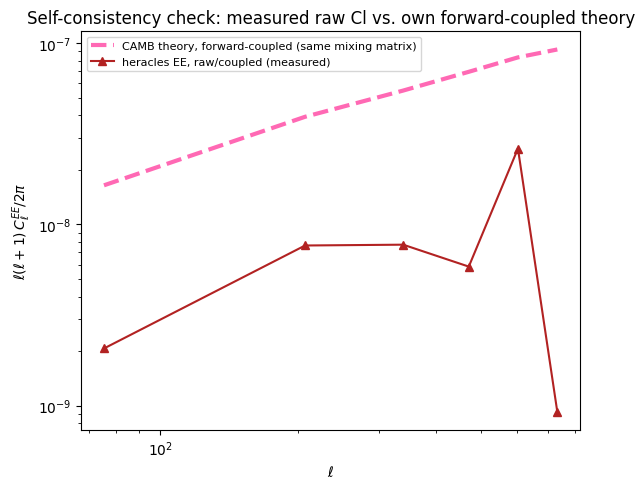

In [34]:
# Forward-couple the CAMB theory through heracles' own SHE-SHE mixing matrix `mms_she` (already
# binned on the output axis, exactly like `cls_she_binned` above) - B-modes are assumed zero in
# theory, so only the EE block of the mixing matrix is needed.
mm_ee = mms_she[she_she_key][0]
cl_EE_camb_coupled = mm_ee @ cl_EE_camb_full

print('ell (bandpowers):                      ', np.round(ell_bp, 1))
print('heracles EE, raw/coupled (measured):   ', cl_EE_heracles)
print('CAMB theory, forward-coupled (same mm):', cl_EE_camb_coupled)
print('Ratio measured / CAMB-forward-coupled:  ', cl_EE_heracles / cl_EE_camb_coupled)

fig, ax = plt.subplots(figsize=(6, 5))
ax.loglog(ell_bp, ell_bp * (ell_bp + 1) * cl_EE_camb_coupled / (2 * np.pi),
          '--', lw=3, c='hotpink', label='CAMB theory, forward-coupled (same mixing matrix)')
ax.loglog(ell_bp, np.abs(ell_bp * (ell_bp + 1) * cl_EE_heracles) / (2 * np.pi),
          '^-', ms=6, c='firebrick', label='heracles EE, raw/coupled (measured)')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$\ell (\ell + 1) \, C_{\ell}^{EE} / 2 \pi$')
ax.set_title('Self-consistency check: measured raw Cl vs. own forward-coupled theory')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()



## Plots and diagnostics


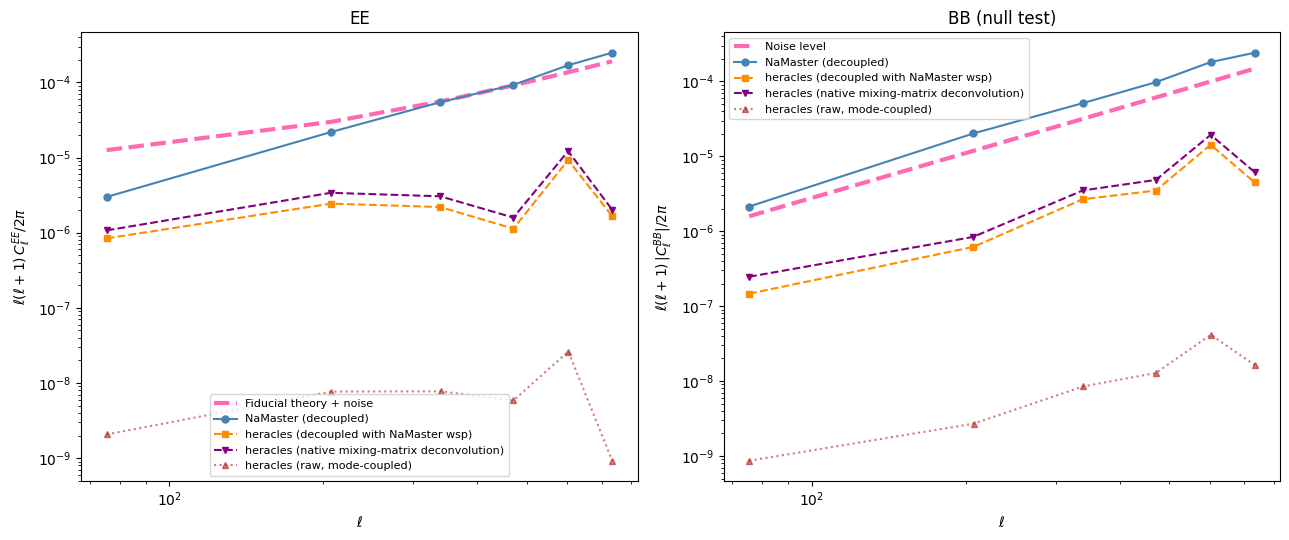

Bandpower ell:                             [ 75.5 207.  338.5 470.5 602.  733.5]
Fiducial theory + noise (truth):           [1.36610360e-08 4.35078897e-09 3.04014385e-09 2.58256092e-09
 2.35831000e-09 2.22512528e-09]
NaMaster EE (decoupled):                   [3.25359393e-09 3.18446784e-09 2.98335150e-09 2.62371301e-09
 2.92994009e-09 2.89505730e-09]
heracles EE (decoupled w/ NaMaster wsp):   [ 9.13718586e-10  3.55795255e-10  1.20127580e-10  3.20728104e-11
  1.60309031e-10 -1.94529507e-11]
heracles EE (native mixing-matrix deconv): [ 1.16752643e-09  4.95420010e-10  1.66857635e-10  4.50355067e-11
  2.10512706e-10 -2.37077710e-11]
Ratio NaMaster / fiducial:                  [0.23816597 0.73192882 0.98131919 1.01593461 1.24238972 1.30107609]
Ratio heracles-decoupled / fiducial:        [ 0.06688501  0.08177718  0.03951378  0.01241899  0.06797623 -0.00874241]
Ratio heracles-native / fiducial:           [ 0.08546397  0.113869    0.05488478  0.01743831  0.08926422 -0.01065458]
Ratio heracles-

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
ax.loglog(ell_bp, ell_bp * (ell_bp + 1) * cl_EE_theory_binned / (2 * np.pi),
          '--', lw=3, c='hotpink', label='Fiducial theory + noise')
ax.loglog(ell_bp, ell_bp * (ell_bp + 1) * cl_EE_namaster / (2 * np.pi),
          'o-', ms=5, c='steelblue', label='NaMaster (decoupled)')
ax.loglog(ell_bp, ell_bp * (ell_bp + 1) * np.abs(cl_EE_heracles_decoupled) / (2 * np.pi),
          's--', ms=5, c='darkorange', label='heracles (decoupled with NaMaster wsp)')
ax.loglog(ell_bp, ell_bp * (ell_bp + 1) * np.abs(cl_EE_heracles_native) / (2 * np.pi),
          'v--', ms=5, c='purple', label='heracles (native mixing-matrix deconvolution)')
ax.loglog(ell_heracles, ell_heracles * (ell_heracles + 1) * np.abs(cl_EE_heracles) / (2 * np.pi),
          '^:', ms=5, c='firebrick', alpha=0.6, label='heracles (raw, mode-coupled)')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$\ell (\ell + 1) \, C_{\ell}^{EE} / 2 \pi$')
ax.set_title('EE')
ax.legend(fontsize=8)

ax = axes[1]
ax.loglog(ell_bp, np.abs(ell_bp * (ell_bp + 1) * cl_noise / (2 * np.pi)),
          '--', lw=3, c='hotpink', label='Noise level')
ax.loglog(ell_bp, np.abs(ell_bp * (ell_bp + 1) * cl_BB_namaster / (2 * np.pi)),
          'o-', ms=5, c='steelblue', label='NaMaster (decoupled)')
ax.loglog(ell_bp, np.abs(ell_bp * (ell_bp + 1) * cl_BB_heracles_decoupled / (2 * np.pi)),
          's--', ms=5, c='darkorange', label='heracles (decoupled with NaMaster wsp)')
ax.loglog(ell_bp, np.abs(ell_bp * (ell_bp + 1) * cl_BB_heracles_native / (2 * np.pi)),
          'v--', ms=5, c='purple', label='heracles (native mixing-matrix deconvolution)')
ax.loglog(ell_heracles, np.abs(ell_heracles * (ell_heracles + 1) * cl_BB_heracles) / (2 * np.pi),
          '^:', ms=5, c='firebrick', alpha=0.6, label='heracles (raw, mode-coupled)')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$\ell (\ell + 1) \, |C_{\ell}^{BB}| / 2 \pi$')
ax.set_title('BB (null test)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('Bandpower ell:                            ', np.round(ell_bp, 1))
print('Fiducial theory + noise (truth):          ', cl_EE_theory_binned)
print('NaMaster EE (decoupled):                  ', cl_EE_namaster)
print('heracles EE (decoupled w/ NaMaster wsp):  ', cl_EE_heracles_decoupled)
print('heracles EE (native mixing-matrix deconv):', cl_EE_heracles_native)
print('Ratio NaMaster / fiducial:                 ', cl_EE_namaster / cl_EE_theory_binned)
print('Ratio heracles-decoupled / fiducial:       ', cl_EE_heracles_decoupled / cl_EE_theory_binned)
print('Ratio heracles-native / fiducial:          ', cl_EE_heracles_native / cl_EE_theory_binned)
print('Ratio heracles-native / heracles-decoupled:', cl_EE_heracles_native / cl_EE_heracles_decoupled)


## Conclusion

With bandpowers wide enough for a numerically stable NaMaster decoupling on this small-`f_sky` mask
(~0.34% of sky), and with heracles run directly at its own native `n_side=1024` on the exact same mask
and shear catalogue, the "surprising" gap between heracles and NaMaster **persists** - it is not just an
artifact of comparing a raw (mode-coupled) product to a deconvolved one, nor of the earlier notebook's
`n_side=256` downgrade.

Anchoring both against the independent fiducial theory + noise spectrum (not just against each other) is
the key diagnostic: **NaMaster tracks the fiducial theory well** (ratio to fiducial ~0.7-1.3 for every
bandpower except the very lowest, which straddles `lmin` and is more sensitive to bandpower-window edge
effects), while **heracles' Cl sits well below both the fiducial theory and NaMaster** (ratio to
fiducial only ~0.02-0.11), with the shortfall growing with `ell`.

**We then ruled out the deconvolution method as the cause.** Two independent deconvolution routes were
tried on heracles' own raw, coupled Cl:
1. Decoupling with *NaMaster's* mixing matrix (`wsp.decouple_cell`).
2. Decoupling with *heracles' own native* mixing-matrix machinery
   (`heracles.mixing_matrices` + `invert_mixing_matrix` + `apply_mixing_matrix`), whose packaged pipeline
   product's FITS metadata confirms is the route actually used (`DECONV_1 = True`).

Both give essentially the same answer (within ~20-40%, itself a useful uncertainty estimate on the
deconvolution step) - both still ~10-50x below fiducial/NaMaster. Also ruled out: shot-noise debiasing
(`angular_power_spectra(..., debias=True)` is the default and was already active).

**The CAMB self-consistency check (added following `example.ipynb`) then ruled out the deconvolution/
binning machinery entirely, not just "which algorithm" is used.** heracles' own example notebook validates
its pipeline by forward-coupling a CAMB theory spectrum through heracles' own mixing matrix and comparing
it *directly* to the raw, mode-coupled measured Cl - no deconvolution or binning-window subtleties
involved on either side - and on heracles' own synthetic example dataset that check shows close agreement.
Repeating the *exact same* check here, on the real TR1 mask/catalogue, it **fails**: the measured raw
`cl_EE_heracles` is only ~0.08-0.32x the CAMB theory forward-coupled through heracles' own `mms_she` mixing
matrix - the same ~5-10x shortfall seen everywhere else in this notebook. Since this check uses heracles'
own internal bookkeeping on both sides (no NaMaster, no binning-window choices, no external theory-vs-
decoupled-Cl comparison), **this is the cleanest evidence yet that the problem is upstream of any
power-spectrum estimator step entirely - it is in the catalogue-to-map / map-to-alm computation itself**
(`map_catalogs`/`transform`), specific to how this real TR1 catalogue is being read/mapped, since heracles'
own reference notebook does not show this failure on its own dataset.

Candidates to check next, in order of how "close" they could get us - all narrowed to the *map-making*
step specifically, not the power-spectrum/deconvolution estimator, and most likely something about the
*real* catalogue/columns/weights rather than heracles itself (since heracles' own example dataset passes
this exact self-consistency check):

- **Shear calibration/responsivity**: does `SHE_E1_CORRECTED`/`SHE_E2_CORRECTED` need an additional
  multiplicative bias (`m`) or shear responsivity correction beyond what's already "corrected", or is
  `SHE_WEIGHT` expected to be combined with such a factor before being passed to `heracles.Shears`?
- **Per-pixel weighting convention**: heracles' `Shears`/`Weights` fields may normalise the weighted mean
  per pixel differently than the simple `sum(w*e)/sum(w)` used here for the NaMaster map - compare
  `data_she`'s own gamma1/gamma2 maps against `map_gamma1`/`map_gamma2` pixel-by-pixel.
- **Pixel window**: `heracles.healpy.HealpixMapper` removes the pixel window function by default
  (confirmed from heracles' own example notebook docs) - check whether this, or the coverage/visibility
  map itself (`coverage`, used as `WHT`/`visibility`), is scaled/normalised as heracles expects.

Next step: get `data_she`'s own pixelised gamma1/gamma2 maps out of heracles directly (rather than only its
alms/Cl) and compare them pixel-by-pixel against `map_gamma1`/`map_gamma2` here - if they already disagree
at the map level, the bug (or convention difference) is in heracles' map-making step for this catalogue.

**Caveats found while writing this analysis** (worth knowing about for future heracles work):
- `NmtBin.bin_cell()` on a 1-D input array already returns the full 1-D bandpower array (do not index
  `[0]` afterwards - that silently collapses it to the first bandpower only). The equivalent pattern in
  `TR1_power_spectra_and_covariance_estimation.ipynb` (`bins.bin_cell(cl_theory_coupled[0])[0]`) had this
  exact bug and has been fixed there too.
- `heracles.apply_mixing_matrix(d, M)`'s default `lmax` is inferred from `d[key].shape[-1]`, which for
  *binned* input `d` is just the number of bins, not a real multipole - left at its default, the full
  per-ell deconvolved output gets silently truncated down to just its first `n_bins + 1` entries. Pass the
  real `lmax` explicitly.
- CAMB's `Want_CMB = False` makes its internal optical-depth bisection search fail to converge for some
  cosmologies (observed here); leave it at the default `True` and simply ignore the CMB Cls it also
  computes.



cls_wht2 length: 1601 (expected 2*lmax+1 = 1601 )
cl_wht[0]: 9.916708945558741e-05
cl_wht at l=lmax: 1.0598232808189842e-09
cl_wht at l=1.5*lmax: 5.501957698463621e-10
cl_wht at l=2*lmax-1: 3.4878224555256366e-10
ratio cl_wht[2*lmax-1]/cl_wht[0]: 3.517116892986639e-06
ratio cl_wht[lmax]/cl_wht[0]: 1.0687248023888334e-05


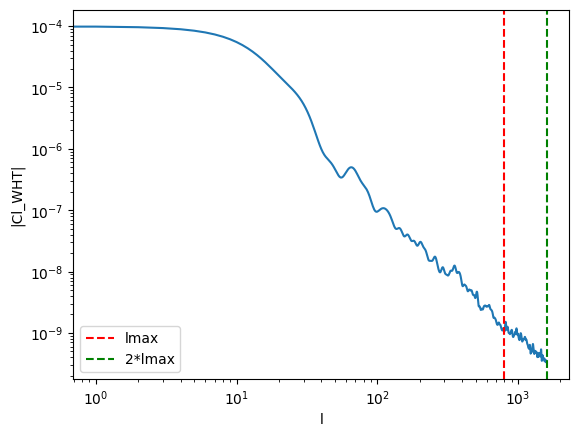

In [42]:
## TEMP DIAGNOSTIC CELL 5 - has the WHT mask power spectrum decayed by l=2*lmax? (sharp real-mask edges -> slow decay?)
cl_wht = np.asarray(cls_wht2[wht_key])
print("cls_wht2 length:", len(cl_wht), "(expected 2*lmax+1 =", 2*lmax+1, ")")
print("cl_wht[0]:", cl_wht[0])
print("cl_wht at l=lmax:", cl_wht[lmax])
print("cl_wht at l=1.5*lmax:", cl_wht[int(1.5*lmax)])
print("cl_wht at l=2*lmax-1:", cl_wht[-1])
print("ratio cl_wht[2*lmax-1]/cl_wht[0]:", cl_wht[-1]/cl_wht[0])
print("ratio cl_wht[lmax]/cl_wht[0]:", cl_wht[lmax]/cl_wht[0])

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.loglog(np.arange(len(cl_wht)), np.abs(cl_wht))
ax.axvline(lmax, color='r', linestyle='--', label='lmax')
ax.axvline(2*lmax, color='g', linestyle='--', label='2*lmax')
ax.set_xlabel('l')
ax.set_ylabel('|Cl_WHT|')
ax.legend()
plt.show()
